#### [실습] 수출입 동향 데이터과 가격/기온/강수량/물가지수 병합
1. 월별 가격/기온/강수량/물가지수의 데이터를 연도기준으로 통합
2. 수출입동향 데이터와 병합
3. 수출입 동향 데이터를 월별 데이터로 복제
4. 월별 가격/기온/강수량/물가지수와 병합
5. 연도별 병합자료, 월별 병합자료에 대한 상관분석(price와 수출입동향간의 관계)
6. 종속변수(price)를 제외한 독립변수가 상관도가 높다면, 변수 선택(차원 축소)

1) 수출입은 년도별로 나머지는 월별 -> 데이터 크게 만들어서 채워보자(복제)<br>
2) 월별데이터를 년도로 통합해서 년도별 데이터로 만들기

3) 병합된 데이터로 상관분석 해보기

데이터 구조상 완벽하게 오버,언더샘플링 하기 힘들다.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. 월별 가격/기온/강수량/물가지수의 데이터 연도기준으로 통합

In [4]:
df_price_merge = pd.read_csv('/content/drive/MyDrive/taxis/df_price_merge.csv')
df_price_merge.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177


In [5]:
df_price_merge['date'].dtypes # object
df_price_merge['date'] = pd.to_datetime(df_price_merge['date'])
df_price_merge['date'].dtypes # datetime으로 변경

# year, month 컬럼 추가
df_price_merge['year'] = df_price_merge['date'].dt.year
df_price_merge['month'] = df_price_merge['date'].dt.month
df_price_merge.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,month
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028,2020,1
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558,2020,2
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009,2020,3
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571,2020,4
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177,2020,5


In [6]:
df_trade = pd.read_csv('/content/drive/MyDrive/taxis/df_trade.csv')
df_trade.head()

,Unnamed: 0,수출,수입,무역수지
0,2014,5224,19308,-25453
1,2015,5221,17902,-24117
2,2016,5581,17666,-23208
3,2017,6047,18594,-25467
4,2018,5985,19903,-28376


In [7]:
df_trade = df_trade.rename(columns={'Unnamed: 0':'년도'})
df_trade.head()

,년도,수출,수입,무역수지
0,2014,5224,19308,-25453
1,2015,5221,17902,-24117
2,2016,5581,17666,-23208
3,2017,6047,18594,-25467
4,2018,5985,19903,-28376


2. 수출입데이터와 병합 / 월별데이터로 복제

In [8]:
# 오버샘플링
merge_over = pd.merge(df_price_merge, df_trade ,left_on ='year', right_on='년도', how='left')
merge_over = merge_over.drop(columns={'년도'})
merge_over.head()

# year을 기준으로 월별 똑같이 복사

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,month,수출,수입,무역수지
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028,2020,1,6675.0,20669.0,-26715.0
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558,2020,2,6675.0,20669.0,-26715.0
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009,2020,3,6675.0,20669.0,-26715.0
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571,2020,4,6675.0,20669.0,-26715.0
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177,2020,5,6675.0,20669.0,-26715.0


3. df_price_merge의 월별데이터를 년도로 통합해서 수출입 데이터와 병합해 년도별 데이터로 만들기

In [9]:
df_price_merge_yearly = df_price_merge.groupby('year').mean().reset_index()
# reset_index()는 groupby로 'year'을 index로 설정한것을 다시 0, 1, 2,.. 원래의 인덱스로 돌려놓는다.
# 숫자형만 평균값을 구하고 싶을 때
#df_price_merge_yearly = df_price_merge.groupby('년도').mean(numeric_only=True).reset_index()

#date와 month의 평균은 필요없으므로 제외
df_price_merge_yearly = df_price_merge_yearly.drop(columns = ['date','month'])
df_price_merge_yearly

,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z
0,2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811
1,2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405
2,2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027
3,2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275
4,2024,4794.666667,14.858333,109.283333,113.498333,124.136667,14.883333,115.966667,-16.039296,-9.578496,0.032292


In [10]:
# 언더 샘플링
merge_under = pd.merge(df_price_merge_yearly, df_trade, left_on='year', right_on='년도', how='left')
# how를 별도로 넣지 않으면 inner join 으로 결측치 없앨 수 있다.
merge_under

,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,년도,수출,수입,무역수지
0,2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811,2020.0,6675.0,20669.0,-26715.0
1,2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405,2021.0,7543.0,25289.0,-33346.0
2,2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027,2022.0,7714.0,29764.0,-39747.0
3,2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275,2023.0,7994.0,27288.0,-34659.0
4,2024,4794.666667,14.858333,109.283333,113.498333,124.136667,14.883333,115.966667,-16.039296,-9.578496,0.032292,NaN,NaN,NaN,NaN


In [11]:
merge_over = merge_over.dropna() # 2024년 결측치 drop
merge_over.rename(columns={"수출" : "export",
                           "수입" : "import",
                           "무역수지" : "tradebalance"}, inplace = True) # 수출이 수입을 초과 하는지 안하는지 (흑자/적자)
merge_over.info() # 결측치 없음
merge_under = merge_under.dropna() # 2024년 결측치 drop
merge_under.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 47
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           48 non-null     datetime64[ns]
 1   price          48 non-null     int64         
 2   temperature    48 non-null     float64       
 3   rain           48 non-null     float64       
 4   index_total    48 non-null     float64       
 5   index_agr      48 non-null     float64       
 6   temperature+m  48 non-null     float64       
 7   rain+m         48 non-null     float64       
 8   temp*rain      48 non-null     float64       
 9   temp*rain+1    48 non-null     float64       
 10  temp*rain_Z    48 non-null     float64       
 11  year           48 non-null     int32         
 12  month          48 non-null     int32         
 13  export         48 non-null     float64       
 14  import         48 non-null     float64       
 15  tradebalance   48 non-null    

<ipython-input-11-f6a2c1d2f434>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_over.rename(columns={"수출" : "export",


In [23]:
corr_price_monthly = merge_over.iloc[:,1:].corr()
corr_price_monthly

,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,month,export,import,tradebalance
price,1.000000,0.469703,0.378532,-0.097476,0.281011,0.529534,0.783533,0.379170,0.783499,0.715332,-2.011095e-01,1.944063e-01,-0.247844,-1.183078e-01,9.197788e-02
temperature,0.469703,1.000000,0.682038,0.206410,0.193805,0.844264,0.578140,0.683651,0.579500,0.772953,2.259773e-02,2.290368e-01,0.023128,7.925740e-03,-3.973965e-03
rain,0.378532,0.682038,1.000000,0.112052,0.035401,0.593194,0.443509,0.999998,0.444385,0.563516,2.784943e-02,1.725570e-01,-0.007755,2.737285e-02,-2.583591e-02
index_total,-0.097476,0.206410,0.112052,1.000000,0.110393,0.310824,0.189684,0.112444,0.190233,0.271883,7.219400e-01,2.796779e-01,0.649097,3.478495e-01,-2.393651e-01
index_agr,0.281011,0.193805,0.035401,0.110393,1.000000,0.301747,0.266966,0.035913,0.267324,0.309303,-4.015102e-01,1.974548e-01,-0.230110,-4.106862e-01,3.910167e-01
temperature+m,0.529534,0.844264,0.593194,0.310824,0.301747,1.000000,0.689014,0.594520,0.690615,0.917850,2.132571e-02,6.444686e-01,0.024717,1.964587e-02,-1.817906e-02
rain+m,0.783533,0.578140,0.443509,0.189684,0.266966,0.689014,1.000000,0.444339,0.999998,0.920084,1.088705e-02,3.892800e-01,-0.022308,1.841598e-02,-1.928085e-02
temp*rain,0.379170,0.683651,0.999998,0.112444,0.035913,0.594520,0.444339,1.000000,0.445218,0.564688,2.786023e-02,1.728927e-01,-0.007670,2.734035e-02,-2.579466e-02
temp*rain+1,0.783499,0.579500,0.444385,0.190233,0.267324,0.690615,0.999998,0.445218,1.000000,0.920948,1.092922e-02,3.904273e-01,-0.022186,1.843716e-02,-1.929574e-02
temp*rain_Z,0.715332,0.772953,0.563516,0.271883,0.309303,0.917850,0.920084,0.564688,0.920948,1.000000,1.748898e-02,5.615303e-01,0.001142,2.070446e-02,-2.038533e-02


<Axes: >

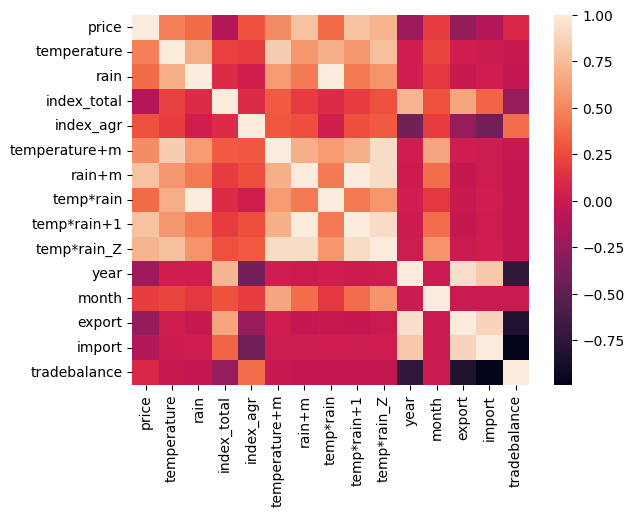

In [24]:
sns.heatmap(corr_price_monthly, fmt ='.2f')

In [14]:
merge_under.drop(columns=['년도'], inplace = True)
merge_under.rename(columns={"수출" : "export",
                           "수입" : "import",
                           "무역수지" : "tradebalance"}, inplace = True)
merge_under.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           4 non-null      int32  
 1   price          4 non-null      float64
 2   temperature    4 non-null      float64
 3   rain           4 non-null      float64
 4   index_total    4 non-null      float64
 5   index_agr      4 non-null      float64
 6   temperature+m  4 non-null      float64
 7   rain+m         4 non-null      float64
 8   temp*rain      4 non-null      float64
 9   temp*rain+1    4 non-null      float64
 10  temp*rain_Z    4 non-null      float64
 11  export         4 non-null      float64
 12  import         4 non-null      float64
 13  tradebalance   4 non-null      float64
dtypes: float64(13), int32(1)
memory usage: 464.0 bytes


<ipython-input-14-18ecee8963c0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_under.drop(columns=['년도'], inplace = True)
<ipython-input-14-18ecee8963c0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_under.rename(columns={"수출" : "export",


In [15]:
core_price_yearly = merge_under.corr()
core_price_yearly

,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,export,import,tradebalance
year,1.000000,-0.589571,0.644847,0.218443,0.842506,-0.537789,0.829246,0.085740,0.219059,0.086277,0.270587,0.936762,0.815549,-0.727404
price,-0.589571,1.000000,-0.935033,0.639383,-0.789236,-0.362671,-0.870129,0.743900,0.638839,0.743564,0.613279,-0.726578,-0.346830,0.269642
temperature,0.644847,-0.935033,1.000000,-0.439174,0.925696,0.214304,0.758664,-0.567138,-0.438503,-0.566823,-0.447062,0.659967,0.226168,-0.113401
rain,0.218443,0.639383,-0.439174,1.000000,-0.073192,-0.928917,-0.333173,0.988877,1.000000,0.988941,0.992340,-0.060831,0.214705,-0.202650
index_total,0.842506,-0.789236,0.925696,-0.073192,1.000000,-0.168546,0.750219,-0.220628,-0.072449,-0.220224,-0.076047,0.757498,0.405941,-0.279340
index_agr,-0.537789,-0.362671,0.214304,-0.928917,-0.168546,1.000000,-0.033579,-0.881896,-0.929077,-0.882158,-0.956105,-0.308213,-0.550079,0.523734
temperature+m,0.829246,-0.870129,0.758664,-0.333173,0.750219,-0.033579,1.000000,-0.440673,-0.332664,-0.440173,-0.259089,0.961118,0.763926,-0.706889
rain+m,0.085740,0.743900,-0.567138,0.988877,-0.220628,-0.881896,-0.440673,1.000000,0.988766,1.000000,0.981189,-0.175684,0.145033,-0.151844
temp*rain,0.219059,0.638839,-0.438503,1.000000,-0.072449,-0.929077,-0.332664,0.988766,1.000000,0.988830,0.992330,-0.060304,0.214971,-0.202818
temp*rain+1,0.086277,0.743564,-0.566823,0.988941,-0.220224,-0.882158,-0.440173,1.000000,0.988830,1.000000,0.981296,-0.175137,0.145546,-0.152323


In [16]:
core_price_yearly['price'] # price 기준 확인

,price
year,-0.589571
price,1.000000
temperature,-0.935033
rain,0.639383
index_total,-0.789236
index_agr,-0.362671
temperature+m,-0.870129
rain+m,0.743900
temp*rain,0.638839
temp*rain+1,0.743564


<Axes: >

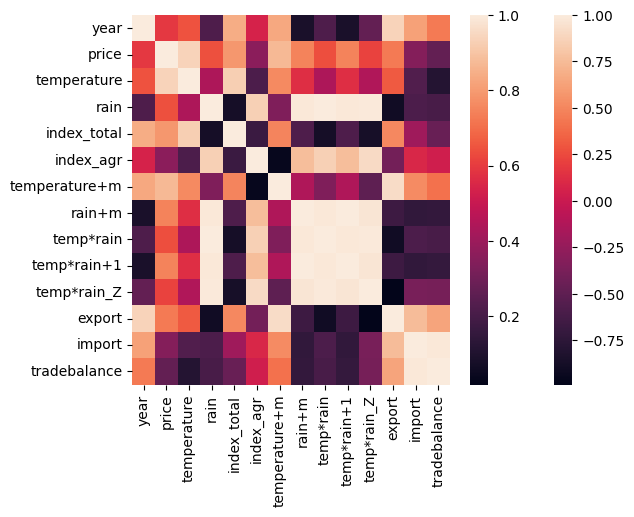

In [30]:
sns.heatmap(core_price_yearly, fmt='.2f')

# 아예 히트맵을 절대값으로 만들어서 볼 수 있다 상관관계에대해서 보기 편할 수 있음
sns.heatmap(abs(core_price_yearly))

- yearly 분석<br>
  - price - temp : 온도가 높을수록 가격 낮아지는 강한 음의 상관관계
  - price - rain : 강수량이 많을수록 가격이 오르는 중간 양의 상관관계
  - price - index_total : 종합 소비자 물가 지수 높을수록 가격 낮아짐
  - price - export : 수출량 많을수록 가격 낮아짐

  - temp - index_total: 온도높을 수록 지수 상승 (강한 양의 상관관계)
  - temp - export : 온도 높을수록 수출 증가 (중간 양의 상관관계)

  - import - export : 수출 수입 강한 양의 상관관계
  - import - tradebalance : 수입 증가할수록 무역수지 감소 (강한 음의 상관관계)


- monthly 분석
  - price - temp+m 중간 양의 상관관계
  - temp - rain 중간 양의 상관관계
  - temp*rain - temp*rain+1
    : 매우 강한 상관관계 (하나 선택)
  - index_total / index_agr : 기후변수들, pric와 낮은 상관관계
  - import - export : 강한 상관관계
  - export, import - tradebalance : 음의 상관관계

### 년도별 데이터 통합 분석
 export , import, trade_index 세개의 상관관계가 높으니 차원 축소

In [19]:
#export와 index_total간의 상관관계가 높으나, index_total은 price와 상관관계 낮아 제외고려
# export, import, trade_index간의 상관관계가 높음 > 차원 축소
from sklearn.decomposition import PCA
# 상관도가 높은 컬럼 세개 선택
selected = merge_under.loc[:, ['export', 'import','tradebalance']]
pca = PCA(n_components=0.95)
trade_year_pca = pca. fit_transform(selected)
trade_year_pca.shape

(4, 1)

In [20]:
# 축소된 차원 컬럼 추가
merge_under['trade'] = trade_year_pca
merge_under

<ipython-input-20-468621900841>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_under['trade'] = trade_year_pca


,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,export,import,tradebalance,trade
0,2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811,6675.0,20669.0,-26715.0,8606.986395
1,2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405,7543.0,25289.0,-33346.0,484.187758
2,2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027,7714.0,29764.0,-39747.0,-7317.245000
3,2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275,7994.0,27288.0,-34659.0,-1773.929152


### 월별 데이터 통합분석

In [22]:
merge_over.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 47
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           48 non-null     datetime64[ns]
 1   price          48 non-null     int64         
 2   temperature    48 non-null     float64       
 3   rain           48 non-null     float64       
 4   index_total    48 non-null     float64       
 5   index_agr      48 non-null     float64       
 6   temperature+m  48 non-null     float64       
 7   rain+m         48 non-null     float64       
 8   temp*rain      48 non-null     float64       
 9   temp*rain+1    48 non-null     float64       
 10  temp*rain_Z    48 non-null     float64       
 11  year           48 non-null     int32         
 12  month          48 non-null     int32         
 13  export         48 non-null     float64       
 14  import         48 non-null     float64       
 15  tradebalance   48 non-null    

In [25]:
# 월별에 비해 년도별이 더 가격과 상관관계가 높은 것을 볼 수 있다 더 영향을 미침
# 상관도가 높은 컬럼 세개 선택
selected = merge_over.loc[:, ['export', 'import','tradebalance']]
pca = PCA(n_components=0.95)
trade_pca = pca. fit_transform(selected)
trade_pca.shape

(48, 1)

In [28]:
# 축소된 차원 컬럼 추가
merge_over['trade'] = trade_pca
merge_over.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,month,export,import,tradebalance,trade
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028,2020,1,6675.0,20669.0,-26715.0,8606.986395
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558,2020,2,6675.0,20669.0,-26715.0,8606.986395
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009,2020,3,6675.0,20669.0,-26715.0,8606.986395
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571,2020,4,6675.0,20669.0,-26715.0,8606.986395
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177,2020,5,6675.0,20669.0,-26715.0,8606.986395
